In [ ]:
import random
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
from collections import Counter, defaultdict

from nltk import pos_tag
import spacy

from nltk.tokenize import sent_tokenize, word_tokenize

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\valde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\valde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\valde\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


---
### 1. Preparación de la muestra de trabajo

In [3]:
df_novelas = pd.read_csv('gutenberg_novels_dataset.csv')
print(df_novelas[['gutenberg_id', 'title', 'author', 'text_length']].to_string(index=False))

 gutenberg_id               title       author  text_length
         1342 Pride and Prejudice  Jane Austen       728392
           84        Frankenstein Mary Shelley       419290
          345             Dracula  Bram Stoker       845805


In [4]:
MARCAS_INICIO = {
    'Pride and Prejudice': 'It is a truth universally acknowledged',
    'Frankenstein': '_To Mrs. Saville, England._',
    'Dracula': 'How these papers have been placed in sequence',
}

METADATA = {
    'Pride and Prejudice': {'autor': 'Jane Austen', 'año': 1813},
    'Frankenstein': {'autor': 'Mary Shelley', 'año': 1818},
    'Dracula': {'autor': 'Bram Stoker', 'año': 1897},
}


def extraer_texto_novela(texto_completo, titulo):
    inicio_gutenberg = texto_completo.find('*** START OF THE PROJECT GUTENBERG')
    fin_gutenberg = texto_completo.find('*** END OF THE PROJECT GUTENBERG')

    if inicio_gutenberg != -1:
        inicio_linea = texto_completo.find('\n', inicio_gutenberg)
        texto = texto_completo[inicio_linea + 1:]
    else:
        texto = texto_completo

    if fin_gutenberg != -1:
        fin_relativo = texto.find('*** END OF THE PROJECT GUTENBERG')
        if fin_relativo != -1:
            texto = texto[:fin_relativo]

    marca_inicio = MARCAS_INICIO[titulo]
    posicion = texto.find(marca_inicio)
    if posicion != -1:
        texto = texto[posicion:]

    texto = re.sub(r'\[Illustration:.*?\]', ' ', texto, flags=re.DOTALL)
    texto = re.sub(r'\n{3,}', '\n\n', texto)
    return texto.strip()


novelas = {}

for _, fila in df_novelas.iterrows():
    titulo = fila['title']
    texto = extraer_texto_novela(fila['text'], titulo)
    novelas[titulo] = {
        'autor': METADATA[titulo]['autor'],
        'año': METADATA[titulo]['año'],
        'texto': texto,
    }
    print(f"{titulo} ({novelas[titulo]['autor']}, {novelas[titulo]['año']})")
    print(f"Caracteres: {len(texto):,}")
    print("Inicio del texto:")
    print(texto[:280].replace('\n', ' '))
    print()

Pride and Prejudice (Jane Austen, 1813)
Caracteres: 689,380
Inicio del texto:
It is a truth universally acknowledged, that a single man in possession of a good fortune must be in want of a wife.  However little known the feelings or views of such a man may be on his first entering a neighbourhood, this truth is so well fixed in the minds of the surrounding

Frankenstein (Mary Shelley, 1818)
Caracteres: 418,770
Inicio del texto:
_To Mrs. Saville, England._  St. Petersburgh, Dec. 11th, 17—.  You will rejoice to hear that no disaster has accompanied the commencement of an enterprise which you have regarded with such evil forebodings. I arrived here yesterday, and my first task is to assure my dear sister o

Dracula (Bram Stoker, 1897)
Caracteres: 843,955
Inicio del texto:
How these papers have been placed in sequence will be made manifest in the reading of them. All needless matters have been eliminated, so that a history almost at variance with the possibilities of later-day belief may s

In [5]:
def segmentar_y_tokenizar(texto, language='english'):
    oraciones = []
    for oracion in sent_tokenize(texto, language=language):
        tokens = word_tokenize(oracion, language=language)
        if tokens:
            oraciones.append({
                'texto': oracion.strip(),
                'tokens': tokens,
            })
    return oraciones


for titulo, info in novelas.items():
    oraciones = segmentar_y_tokenizar(info['texto'])
    info['oraciones'] = oraciones
    info['n_oraciones'] = len(oraciones)
    info['n_tokens'] = sum(len(o['tokens']) for o in oraciones)
    print(f"{titulo}")
    print(f"- Oraciones: {info['n_oraciones']:,}")
    print(f"- Tokens:    {info['n_tokens']:,} \n")

Pride and Prejudice
- Oraciones: 4,652
- Tokens:    144,189 

Frankenstein
- Oraciones: 3,075
- Tokens:    85,466 

Dracula
- Oraciones: 7,355
- Tokens:    190,806 



In [6]:
SEMILLA = 42

def seleccionar_muestra(oraciones, n=120, semilla=SEMILLA):
    candidatas = [o for o in oraciones if len(o['tokens']) >= 5]
    if len(candidatas) < n:
        raise ValueError(f"Solo hay {len(candidatas)} oraciones candidatas; se pidieron {n}.")

    n_bloques = 4
    por_bloque = n // n_bloques
    resto = n % n_bloques
    tamanio_bloque = len(candidatas) // n_bloques

    muestra = []
    rng = random.Random(semilla)

    for i in range(n_bloques):
        inicio = i * tamanio_bloque
        fin = len(candidatas) if i == n_bloques - 1 else (i + 1) * tamanio_bloque
        bloque = candidatas[inicio:fin]
        k = por_bloque + (1 if i < resto else 0)
        muestra.extend(rng.sample(bloque, k))

    rng.shuffle(muestra)
    return muestra


for titulo, info in novelas.items():
    muestra = seleccionar_muestra(info['oraciones'])
    info['muestra'] = muestra
    info['n_oraciones_muestra'] = len(muestra)
    info['n_tokens_muestra'] = sum(len(o['tokens']) for o in muestra)
    print(f"{titulo}: muestra de {info['n_oraciones_muestra']} oraciones "
          f"({info['n_tokens_muestra']:,} tokens)")

Pride and Prejudice: muestra de 120 oraciones (3,913 tokens)
Frankenstein: muestra de 120 oraciones (3,764 tokens)
Dracula: muestra de 120 oraciones (3,137 tokens)


In [7]:
filas = []
for titulo, info in novelas.items():
    filas.append({
        'Libro': titulo,
        'Oraciones (libro completo)': info['n_oraciones'],
        'Tokens (libro completo)': info['n_tokens'],
        'Oraciones (muestra)': info['n_oraciones_muestra'],
        'Tokens (muestra)': info['n_tokens_muestra']
    })

tabla_muestras = pd.DataFrame(filas)

tabla_mostrar = tabla_muestras.copy()
for col in ['Oraciones (libro completo)', 'Tokens (libro completo)', 'Tokens (muestra)']:
    tabla_mostrar[col] = tabla_mostrar[col].map(lambda x: f"{x:,}")

tabla_mostrar

,Libro,Oraciones (libro completo),Tokens (libro completo),Oraciones (muestra),Tokens (muestra)
0,Pride and Prejudice,"4,652","144,189",120,"3,913"
1,Frankenstein,"3,075","85,466",120,"3,764"
2,Dracula,"7,355","190,806",120,"3,137"


In [8]:
n = 0
for titulo, info in novelas.items():
    ejemplo = info['muestra'][0]
    print(f"{titulo} — {info['autor']}")
    print(f"  Texto:  {ejemplo['texto']}")
    print(f"  Tokens: {ejemplo['tokens']}")
    if n != 2:
        print("\n-----------------------------------------------------------\n")
    n += 1

Pride and Prejudice — Jane Austen
  Texto:  It is not that I do not believe _my_ fingers
as capable as any other woman’s of superior execution.”

Darcy smiled and said, “You are perfectly right.
  Tokens: ['It', 'is', 'not', 'that', 'I', 'do', 'not', 'believe', '_my_', 'fingers', 'as', 'capable', 'as', 'any', 'other', 'woman', '’', 's', 'of', 'superior', 'execution.', '”', 'Darcy', 'smiled', 'and', 'said', ',', '“', 'You', 'are', 'perfectly', 'right', '.']

-----------------------------------------------------------

Frankenstein — Mary Shelley
  Texto:  She seemed
pleased and went into the garden for some roots and plants, which she
placed in water, and then upon the fire.
  Tokens: ['She', 'seemed', 'pleased', 'and', 'went', 'into', 'the', 'garden', 'for', 'some', 'roots', 'and', 'plants', ',', 'which', 'she', 'placed', 'in', 'water', ',', 'and', 'then', 'upon', 'the', 'fire', '.']

-----------------------------------------------------------

Dracula — Bram Stoker
  Texto:  I took th

---

### 2. Etiquetado gramatical (POS tagging)

In [9]:
def etiqueta_general(tag):
    if tag.startswith('NN'):
        return 'NOUN'
    if tag.startswith('VB'):
        return 'VERB'
    if tag.startswith('JJ'):
        return 'ADJ'
    if tag.startswith('RB'):
        return 'ADV'
    if tag.startswith('PRP'):
        return 'PRON'
    if tag in {'DT', 'PDT', 'WDT'}:
        return 'DET'
    if tag in {'IN', 'TO'}:
        return 'ADP'
    if tag in {'CC'}:
        return 'CONJ'
    if tag in {'CD'}:
        return 'NUM'
    if tag in {'MD'}:
        return 'AUX'
    if tag in {'POS'}:
        return 'PART'
    if tag in {'RP'}:
        return 'PART'
    if tag in {'EX'}:
        return 'PRON'
    if tag in {'WP', 'WP$'}:
        return 'PRON'
    if tag in {'WRB'}:
        return 'ADV'
    if tag in {'.', ',', ':', ';', '!', '?', '(', ')', '``', "''", 'SYM', '#', '$'}:
        return 'PUNCT'
    return 'OTHER'

In [12]:
for titulo, info in novelas.items():
    filas_libro = []

    for i, oracion in enumerate(info['muestra']):
        etiquetas = pos_tag(oracion['tokens'], lang='eng')
        oracion['pos_tags'] = etiquetas

        for j, (token, tag) in enumerate(etiquetas):
            filas_libro.append({
                'Libro': titulo,
                'oracion_id': i,
                'token_id': j,
                'token': token,
                'tag': tag,
                'POS': etiqueta_general(tag),
                'oracion': oracion['texto']
            })

    info['pos_df'] = pd.DataFrame(filas_libro)


distribuciones = []
for titulo, info in novelas.items():
    conteo = info['pos_df']['POS'].value_counts()
    total = conteo.sum()

    for pos, frecuencia in conteo.items():
        distribuciones.append({
            'Libro': titulo,
            'POS': pos,
            'Frecuencia': frecuencia,
            'Porcentaje': 100 * frecuencia / total
        })

tabla_pos = pd.DataFrame(distribuciones)

# Tabla comparativa en porcentaje
tabla_pos_pivot = (
    tabla_pos
    .pivot(index='POS', columns='Libro', values='Porcentaje')
    .fillna(0)
    .reindex(['NOUN','VERB','ADJ','ADV','PRON','DET','ADP','CONJ','NUM','AUX','PART','PUNCT','OTHER'])
    .fillna(0)
)

tabla_pos_mostrar = tabla_pos_pivot.round(2)
tabla_pos_mostrar.columns.name = None
tabla_pos_mostrar


,Dracula,Frankenstein,Pride and Prejudice
POS,,,
NOUN,18.90,18.60,19.60
VERB,16.35,16.55,16.69
ADJ,6.18,5.98,6.26
ADV,5.87,5.39,7.62
PRON,12.97,13.31,11.32
DET,8.22,8.66,6.93
ADP,13.04,13.76,13.70
CONJ,3.98,4.94,3.83
NUM,0.48,0.40,0.43


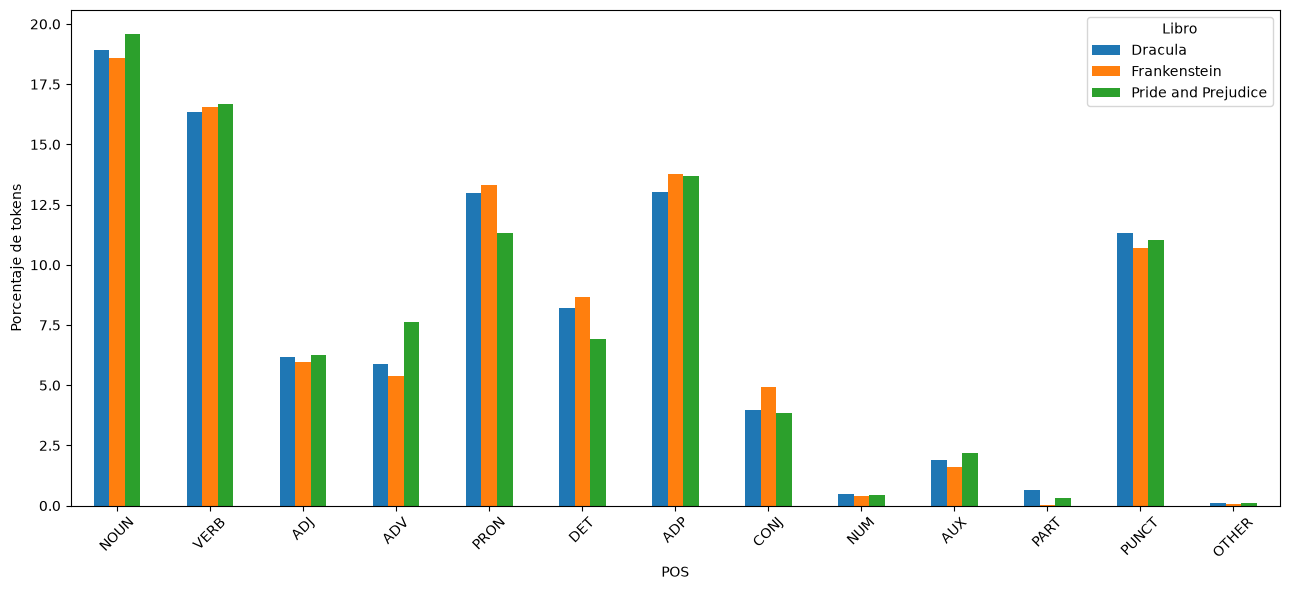

In [17]:
ax = tabla_pos_pivot.plot(kind='bar', figsize=(13, 6))
ax.set_ylabel('Porcentaje de tokens')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Libro')
plt.tight_layout()
plt.show()

In [18]:
def candidatos_ambiguos(df, min_apariciones=2):
    candidatos = []

    temp = df.copy()
    temp['token_lower'] = temp['token'].str.lower()
    temp = temp[temp['token_lower'].str.fullmatch(r"[a-zA-Z]+(?:'[a-zA-Z]+)?", na=False)]

    for palabra, grupo in temp.groupby('token_lower'):
        n_apariciones = len(grupo)
        tags = sorted(grupo['tag'].unique())
        if n_apariciones >= min_apariciones and len(tags) >= 2:
            candidatos.append({
                'palabra': palabra,
                'apariciones': n_apariciones,
                'etiquetas': ', '.join(tags),
                'n_etiquetas': len(tags)
            })

    return (
        pd.DataFrame(candidatos)
        .sort_values(['n_etiquetas', 'apariciones'], ascending=[False, False])
        .reset_index(drop=True)
    )

ambiguedad_por_libro = {}
for titulo, info in novelas.items():
    ambiguedad_por_libro[titulo] = candidatos_ambiguos(info['pos_df'])
    print(f"\n{titulo}")
    display(ambiguedad_por_libro[titulo].head(10))


Pride and Prejudice


,palabra,apariciones,etiquetas,n_etiquetas
0,her,68,"NN, PRP, PRP$",3
1,that,41,"DT, IN, WDT",3
2,s,16,"JJ, NN, VBD",3
3,better,8,"JJR, RB, RBR",3
4,lady,7,"JJ, NN, NNP",3
5,most,6,"JJS, RBS, VB",3
6,think,6,"NN, VB, VBP",3
7,hope,4,"NN, VB, VBP",3
8,make,4,"NNP, VB, VBP",3
9,longer,3,"JJR, RB, RBR",3



Frankenstein


,palabra,apariciones,etiquetas,n_etiquetas
0,that,49,"DT, IN, WDT",3
1,all,11,"DT, PDT, RB",3
2,dear,7,"JJ, NN, NNP",3
3,thought,5,"NN, VBD, VBN",3
4,beloved,4,"JJ, VBD, VBN",3
5,fit,3,"JJ, NNP, VB",3
6,thou,3,"'', CC, VB",3
7,my,82,"NNP, PRP$",2
8,as,29,"IN, RB",2
9,her,21,"PRP, PRP$",2



Dracula


,palabra,apariciones,etiquetas,n_etiquetas
0,s,14,"JJ, NN, VBD, VBP, VBZ",5
1,come,7,"NN, NNP, VB, VBN, VBP",5
2,that,60,"DT, IN, WDT",3
3,as,25,"IN, RB, VB",3
4,are,13,"IN, NNP, VBP",3
5,over,8,"IN, RB, RP",3
6,do,7,"NNP, VB, VBP",3
7,go,5,"NNP, VB, VBP",3
8,look,3,"NN, VB, VBP",3
9,t,3,"IN, NN, VB",3


In [28]:
n = 0

for titulo, info in novelas.items():
    candidatos = ambiguedad_por_libro[titulo].head(3)['palabra'].tolist()
    df = info['pos_df'].copy()
    df['token_lower'] = df['token'].str.lower()

    if n != 0:
        print(f"\n{'=' * 80}\n")
    print(f"{titulo}")

    for palabra in candidatos:
        subset = df[df['token_lower'] == palabra][['token', 'tag', 'POS', 'oracion']].drop_duplicates()
        print(f"\nPalabra: {palabra}")
        display(subset.head(8).reset_index(drop=True))
    n += 1

Pride and Prejudice

Palabra: her


,token,tag,POS,oracion
0,her,PRP$,PRON,You know my mother’s ideas as to the\nnecessit...
1,her,PRP$,PRON,Since her father’s death her\nhome has been Lo...
2,her,PRP,PRON,Since her father’s death her\nhome has been Lo...
3,her,PRP$,PRON,She was busily searching through the neighbour...
4,her,PRP$,PRON,He had not been long seated\nbefore he complim...
5,her,PRP$,PRON,"About the middle of the next day, as she was i..."
6,her,PRP,PRON,"About the middle of the next day, as she was i..."
7,her,PRP,PRON,"When, after examining the mother, in whose cou..."



Palabra: that


,token,tag,POS,oracion
0,that,IN,ADP,It is not that I do not believe _my_ fingers\n...
1,that,IN,ADP,"“From what we have seen of him,” continued Mrs..."
2,that,IN,ADP,He had not been long seated\nbefore he complim...
3,that,IN,ADP,She could not determine how her mother\nwould ...
4,That,IN,ADP,That he should even speak to\nher was amazing!...
5,that,IN,ADP,Lady Catherine was extremely indignant on the ...
6,that,IN,ADP,The possibility of Mr. Collins’s fancying hims...
7,that,DT,DET,The possibility of Mr. Collins’s fancying hims...



Palabra: s


...

,token,tag,POS,oracion
0,s,NN,NOUN,"My household work is done, so I shall take his..."
1,s,VBD,VERB,she is calm in her\nsleep....\n\n_Jonathan Har...
2,s,VBD,VERB,The\ngoods leave by the train at 9:30 to-night...
3,s,NN,NOUN,I heard a man by the name of\nBloxam say four ...
4,s,NN,NOUN,"When it was all over, we were\nstanding beside..."
5,s,VBD,VERB,"When it was all over, we were\nstanding beside..."
6,s,VBP,VERB,Yesterday I was almost willing to accept Van H...
7,s,JJ,ADJ,"I know that, but do you know what day it is?” ..."



Palabra: come


,token,tag,POS,oracion
0,come,NN,NOUN,"“Oh, very well,” he said; “let her come in, by..."
1,come,VB,VERB,I have asked him to come at once.
2,come,VBN,VERB,"At last I felt that subtle change in the air, ..."
3,come,VBP,VERB,"But it\nis pleasure added to do for him, your ..."
4,Come,NNP,NOUN,Come with me.”\n\nHe put on the coffin-lid aga...
5,come,VB,VERB,Then he took over the care of the case\nhimsel...
6,come,VB,VERB,"has it come to\nthis!” and, raising himself to..."



Palabra: that


,token,tag,POS,oracion
0,that,IN,ADP,I took them\nbefore we knew that all was yours...
1,that,IN,ADP,"I scolded him for it, but he argued quietly th..."
2,that,IN,ADP,"He must, indeed, have been that Voivode Dracul..."
3,that,IN,ADP,It was a pity that we had not some\nbetter org...
4,that,DT,DET,"My household work is done, so I shall take his..."
5,that,IN,ADP,"“Then write now, my young friend,” he said, la..."
6,that,IN,ADP,"Well, Mr. Morris sat down beside me and looked..."
7,that,IN,ADP,Remember that we are in\nterrible straits.


**Comente si alguna de esas asignaciones le parece incorrecta, considerando que cada novela pertenece a una época distinta (vocabulario, ortografía y construcciones de su tiempo) y que el tagger fue entrenado con inglés contemporáneo. ¿Hay algún libro donde el tagger cometa visiblemente más errores que en los otros? ¿A qué lo atribuye?**

Sí hay algunas asignaciones incorrectas. En Frankenstein 'thou' sale etiquetado como CC o VB en lugar de pronombre, y en Pride and Prejudice 'lady' alterna entre JJ, NN y NNP aunque en *Lady Catherine* siempre forma parte de un nombre propio. Donde más se equivoca es en Dracula, la forma de escribir de Whitby y el inglés roto de Van Helsing dejan letras como 's' o 't' con cuatro o cinco etiquetas distintas, y algunos nombres extranjeros terminan como sustantivos comunes.

---

### 3. Tagsets y anotación

In [150]:
libro = 'Pride and Prejudice'
info = novelas[libro]

tokens_etiquetados = []

for oracion in info['muestra']:
    etiquetas = pos_tag(oracion['tokens'], lang='eng')

    for token, tag in etiquetas:
        tokens_etiquetados.append({
            'Token': token,
            'POS universal': etiqueta_general(tag),
            'Penn Treebank': tag
        })

muestra_10_tokens = random.sample(tokens_etiquetados, 10)

tabla_10_tokens = pd.DataFrame(muestra_10_tokens)
tabla_10_tokens

,Token,POS universal,Penn Treebank
0,that,ADP,IN
1,mother,NOUN,NN
2,”,NOUN,NNP
3,are,VERB,VBP
4,with,ADP,IN
5,her,PRON,PRP$
6,like,VERB,VB
7,of,ADP,IN
8,I,PRON,PRP
9,saying,VERB,VBG


**¿Qué información adicional aporta el tagset de Penn Treebank frente al tagset universal?**

El tagset de Penn Treebank aporta una clasificación más específica que el tagset universal. Por ejemplo, el tagset universal solo indica categorías generales como NOUN, VERB, PRON o ADP, mientras que Penn Treebank distingue casos más detallados como NN, NNP, PRP$, VB, VBP o VBG. Esto permite ver no solo si una palabra es verbo o sustantivo, sino también su forma gramatical.

In [114]:
libro = 'Pride and Prejudice'
info = novelas[libro]

oraciones = random.sample(info['muestra'], 5)

for i, o in enumerate(oraciones, start=1):
    print(f'ORACIÓN {i}:')
    print(o['texto'] + '\n')

ORACIÓN 1:
The housekeeper
at Netherfield had received orders to prepare for the arrival of her
master, who was coming down in a day or two, to shoot there for several
weeks.

ORACIÓN 2:
But may we not
hope that the period of future happiness, to which Miss Bingley looks
forward, may arrive earlier than she is aware, and that the delightful
intercourse you have known as friends will be renewed with yet greater
satisfaction as sisters?

ORACIÓN 3:
It was a rational scheme, to be sure!

ORACIÓN 4:
Lady Catherine was extremely indignant on the marriage of her nephew;
and as she gave way to all the genuine frankness of her character, in
her reply to the letter which announced its arrangement, she sent him
language so very abusive, especially of Elizabeth, that for some time
all intercourse was at an end.

ORACIÓN 5:
Four sides of paper were
insufficient to contain all her delight, and all her earnest desire of
being loved by her sister.



Oracion 1: The[DT] housekeeper[NN] at[IN] Netherfield[NNP] had[VBD] received[VBN] orders[NNS] to[TO] prepare[VB] for[IN] the[DT] arrival[NN] of[IN] her[PRP$] master[NN],[,] who[WP] was[VBD] coming[VBG] down[RP] in[IN] a[DT] day[NN] or[CC] two[CD],[,] to[TO] shoot[VB] there[RB] for[IN] several[JJ] weeks[NNS].[.]

Oracion 2: But[CC] may[MD] we[PRP] not[RB] hope[VB] that[IN] the[DT] period[NN] of[IN] future[JJ] happiness[NN],[,] to[TO] which[WDT] Miss[NNP] Bingley[NNP] looks[VBZ] forward[RB],[,] may[MD] arrive[VB] earlier[RBR] than[IN] she[PRP] is[VBZ] aware[JJ],[,] and[CC] that[IN] the[DT] delightful[JJ] intercourse[NN] you[PRP] have[VBP] known[VBN] as[IN] friends[NNS] will[MD] be[VB] renewed[VBN] with[IN] yet[RB] greater[JJR] satisfaction[NN] as[IN] sisters[NNS]?[.]

Oracion 3: It[PRP] was[VBD] a[DT] rational[JJ] scheme[NN],[,] to[TO] be[VB] sure[JJ]![.]

Oracion 4: Lady[NNP] Catherine[NNP] was[VBD] extremely[RB] indignant[JJ] on[IN] the[DT] marriage[NN] of[IN] her[PRP$] nephew[NN];[:] and[CC] as[IN] she[PRP] gave[VBD] way[NN] to[TO] all[PDT] the[DT] genuine[JJ] frankness[NN] of[IN] her[PRP$] character[NN],[,] in[IN] her[PRP$] reply[NN] to[TO] the[DT] letter[NN] which[WDT] announced[VBD] its[PRP$] arrangement[NN],[,] she[PRP] sent[VBD] him[PRP] language[NN] so[RB] very[RB] abusive[JJ],[,] especially[RB] of[IN] Elizabeth[NNP],[,] that[IN] for[IN] some[DT] time[NN] all[DT] intercourse[NN] was[VBD] at[IN] an[DT] end[NN].[.]

Oracion 5: Four[CD] sides[NNS] of[IN] paper[NN] were[VBD] insufficient[JJ] to[TO] contain[VB] all[PDT] her[PRP$] delight[NN],[,] and[CC] all[PDT] her[PRP$] earnest[JJ] desire[NN] of[IN] being[VBG] loved[VBN] by[IN] her[PRP$] sister[NN].[.]

In [118]:
manual_anotadas = [
    'The[DT] housekeeper[NN] at[IN] Netherfield[NNP] had[VBD] received[VBN] orders[NNS] to[TO] prepare[VB] for[IN] the[DT] arrival[NN] of[IN] her[PRP$] master[NN],[,] who[WP] was[VBD] coming[VBG] down[RP] in[IN] a[DT] day[NN] or[CC] two[CD],[,] to[TO] shoot[VB] there[RB] for[IN] several[JJ] weeks[NNS].[.]',
    'But[CC] may[MD] we[PRP] not[RB] hope[VB] that[IN] the[DT] period[NN] of[IN] future[JJ] happiness[NN],[,] to[TO] which[WDT] Miss[NNP] Bingley[NNP] looks[VBZ] forward[RB],[,] may[MD] arrive[VB] earlier[RBR] than[IN] she[PRP] is[VBZ] aware[JJ],[,] and[CC] that[IN] the[DT] delightful[JJ] intercourse[NN] you[PRP] have[VBP] known[VBN] as[IN] friends[NNS] will[MD] be[VB] renewed[VBN] with[IN] yet[RB] greater[JJR] satisfaction[NN] as[IN] sisters[NNS]?[.]',
    'It[PRP] was[VBD] a[DT] rational[JJ] scheme[NN],[,] to[TO] be[VB] sure[JJ]![.]',
    'Lady[NNP] Catherine[NNP] was[VBD] extremely[RB] indignant[JJ] on[IN] the[DT] marriage[NN] of[IN] her[PRP$] nephew[NN];[:] and[CC] as[IN] she[PRP] gave[VBD] way[NN] to[TO] all[PDT] the[DT] genuine[JJ] frankness[NN] of[IN] her[PRP$] character[NN],[,] in[IN] her[PRP$] reply[NN] to[TO] the[DT] letter[NN] which[WDT] announced[VBD] its[PRP$] arrangement[NN],[,] she[PRP] sent[VBD] him[PRP] language[NN] so[RB] very[RB] abusive[JJ],[,] especially[RB] of[IN] Elizabeth[NNP],[,] that[IN] for[IN] some[DT] time[NN] all[DT] intercourse[NN] was[VBD] at[IN] an[DT] end[NN].[.]',
    'Four[CD] sides[NNS] of[IN] paper[NN] were[VBD] insufficient[JJ] to[TO] contain[VB] all[PDT] her[PRP$] delight[NN],[,] and[CC] all[PDT] her[PRP$] earnest[JJ] desire[NN] of[IN] being[VBG] loved[VBN] by[IN] her[PRP$] sister[NN].[.]'
]

def parsear_anotacion_manual(texto):
    patron = re.compile(r'(.+?)\[([^\]]+)\]')
    pares = [(token.strip(), tag.strip()) for token, tag in patron.findall(texto)]
    return pares

if all(manual_anotadas):
    resultados_comparacion = []
    for i, (anotacion_manual, oracion) in enumerate(zip(manual_anotadas, oraciones), start=1):
        manual = parsear_anotacion_manual(anotacion_manual)
        automatico = oracion['pos_tags']

        for j, ((token_m, tag_m), (token_a, tag_a)) in enumerate(zip(manual, automatico), start=1):
            if token_m != token_a:
                raise ValueError(
                    f'Diferencia de token en oración {i}, posición {j}: ' 
                    f'manual={token_m!r}, automático={token_a!r}'
                )
            resultados_comparacion.append({
                'Oración': i,
                'Token': token_m,
                'Manual': tag_m,
                'Automático': tag_a,
                'Coincide': tag_m == tag_a
            })

    df_comparacion = pd.DataFrame(resultados_comparacion)
    coincidencias = int(df_comparacion['Coincide'].sum())
    total_tokens = len(df_comparacion)
    porcentaje = 100 * coincidencias / total_tokens if total_tokens else 0

    print(f'Tokens coincidentes: {coincidencias} de {total_tokens}')
    print(f'Porcentaje de coincidencia: {porcentaje:.2f}%')
    print('\nDesacuerdos:')
    display(df_comparacion[~df_comparacion['Coincide']].reset_index(drop=True))

Tokens coincidentes: 168 de 174
Porcentaje de coincidencia: 96.55%

Desacuerdos:


,Oración,Token,Manual,Automático,Coincide
0,1,down,RP,RB,False
1,2,earlier,RBR,JJR,False
2,4,Lady,NNP,JJ,False
3,5,all,PDT,DT,False
4,5,all,PDT,DT,False
5,5,earnest,JJ,JJS,False


**¿En cuántos tokens coincidió el tagger automatico?**

De los 174 tokens etiquetados a mano, el tagger automatico coincidió en 168 con 6 desacuerdos.



**Comente los desacuerdos encontrados: ¿son errores del modelo, ambigüedad genuina, o simplemente diferencias de criterio del tagset?**

Solo 1 de los 6 desacuerdos (down) se debe a ambiguedad del ingles y 2 son diferencia de criterio del tagset. Los otros 3 son errores reales del modelo que tienen que ver con el hecho de que el tagger fue entrenado con ingles mas moderno.

---
### 4. Reconocimiento de entidades nombradas (NER)

In [119]:
def extraer_primeras_tres_secciones(texto, n=3):
    patron = re.compile(r'(?im)^\s*(CHAPTER\s+(?:[IVXLCDM]+|\d+)[^\n]*)\s*$')
    matches = list(patron.finditer(texto))

    if len(matches) >= n:
        inicio = matches[0].start()
        fin = matches[n].start() if len(matches) > n else len(texto)
        fragmento = texto[inicio:fin].strip()
        titulos = [m.group(1).strip() for m in matches[:n]]
        return fragmento, f'Primeras {n} secciones CHAPTER: ' + ' | '.join(titulos)

    fragmento = texto[:40000].strip()
    return fragmento

ner_fragmentos = {}
for titulo, info in novelas.items():
    fragmento, descripcion = extraer_primeras_tres_secciones(info['texto'], n=3)
    ner_fragmentos[titulo] = {'texto': fragmento, 'descripcion': descripcion}
    print(f'\n{titulo}: {descripcion}')
    print(f'Tokens aproximados por espacios: {len(fragmento.split()):,}')


Pride and Prejudice: Primeras 3 secciones CHAPTER: CHAPTER II. | CHAPTER III. | CHAPTER IV.
Tokens aproximados por espacios: 3,567

Frankenstein: Primeras 3 secciones CHAPTER: Chapter 1 | Chapter 2 | Chapter 3
Tokens aproximados por espacios: 6,647

Dracula: Primeras 3 secciones CHAPTER: CHAPTER I | CHAPTER II | CHAPTER III
Tokens aproximados por espacios: 16,915


In [120]:
nlp = spacy.load('en_core_web_sm')

ner_docs = {}
for titulo, data in ner_fragmentos.items():
    ner_docs[titulo] = nlp(data['texto'])

In [121]:
filas_ner_tipo = []
filas_ner_total = []

for titulo, doc in ner_docs.items():
    conteo = Counter(ent.label_ for ent in doc.ents)
    total_entidades = len(doc.ents)
    total_tokens = len([t for t in doc if not t.is_space])

    filas_ner_total.append({
        'Libro': titulo,
        'Tokens analizados': total_tokens,
        'Entidades totales': total_entidades,
        'Entidades por 100 tokens': round(100 * total_entidades / total_tokens, 3) if total_tokens else 0
    })

    for tipo, frecuencia in conteo.items():
        filas_ner_tipo.append({
            'Libro': titulo,
            'Tipo': tipo,
            'Frecuencia': frecuencia,
            'Porcentaje de entidades': round(100 * frecuencia / total_entidades, 2) if total_entidades else 0
        })

tabla_ner_resumen = pd.DataFrame(filas_ner_total)
tabla_ner_tipo = pd.DataFrame(filas_ner_tipo).sort_values(['Libro','Frecuencia'], ascending=[True,False])

display(tabla_ner_resumen)
print('\nDistribución por tipo:')
display(tabla_ner_tipo)

,Libro,Tokens analizados,Entidades totales,Entidades por 100 tokens
0,Pride and Prejudice,4324,175,4.047
1,Frankenstein,7464,155,2.077
2,Dracula,19646,388,1.975



Distribución por tipo:


,Libro,Tipo,Frecuencia,Porcentaje de entidades
25,Dracula,PERSON,77,19.85
33,Dracula,CARDINAL,71,18.30
28,Dracula,GPE,56,14.43
24,Dracula,ORG,42,10.82
29,Dracula,TIME,31,7.99
26,Dracula,DATE,30,7.73
31,Dracula,NORP,28,7.22
30,Dracula,LOC,16,4.12
35,Dracula,ORDINAL,13,3.35
36,Dracula,LANGUAGE,6,1.55


In [122]:
tabla_ner_pivot = (
    tabla_ner_tipo
    .pivot(index='Tipo', columns='Libro', values='Frecuencia')
    .fillna(0)
    .astype(int)
)

tabla_ner_pivot

Libro,Dracula,Frankenstein,Pride and Prejudice
Tipo,,,
CARDINAL,71,15,21
DATE,30,31,8
EVENT,1,0,0
FAC,5,1,1
GPE,56,26,7
LANGUAGE,6,0,0
LAW,2,3,1
LOC,16,2,0
MONEY,0,0,1


In [123]:
def entidades_mas_frecuentes(doc, tipos, n=10):
    conteo = Counter(
        ent.text.strip()
        for ent in doc.ents
        if ent.label_ in tipos and ent.text.strip()
    )
    return conteo.most_common(n)

filas_top_ner = []
for titulo, doc in ner_docs.items():
    person = entidades_mas_frecuentes(doc, {'PERSON'}, 10)
    gpe_loc = entidades_mas_frecuentes(doc, {'GPE','LOC'}, 10)

    for posicion, (entidad, frecuencia) in enumerate(person, 1):
        filas_top_ner.append({
            'Libro': titulo, 'Categoria': 'PERSON',
            'Posicion': posicion, 'Entidad': entidad, 'Frecuencia': frecuencia
        })
    for posicion, (entidad, frecuencia) in enumerate(gpe_loc, 1):
        filas_top_ner.append({
            'Libro': titulo, 'Categoria': 'GPE/LOC',
            'Posicion': posicion, 'Entidad': entidad, 'Frecuencia': frecuencia
        })

tabla_top_ner = pd.DataFrame(filas_top_ner)
tabla_top_person = tabla_top_ner[tabla_top_ner['Categoria'] == 'PERSON'].copy()
tabla_top_gpe_loc = tabla_top_ner[tabla_top_ner['Categoria'] == 'GPE/LOC'].copy()

print('PERSON más frecuentes:')
display(tabla_top_person)
print('GPE/LOC más frecuentes:')
display(tabla_top_gpe_loc)

PERSON más frecuentes:


,Libro,Categoria,Posicion,Entidad,Frecuencia
0,Pride and Prejudice,PERSON,1,Bingley,27
1,Pride and Prejudice,PERSON,2,Bennet,19
2,Pride and Prejudice,PERSON,3,Darcy,11
3,Pride and Prejudice,PERSON,4,Elizabeth,7
4,Pride and Prejudice,PERSON,5,Jane,6
5,Pride and Prejudice,PERSON,6,Hurst,5
6,Pride and Prejudice,PERSON,7,Lizzy,4
7,Pride and Prejudice,PERSON,8,Long,4
8,Pride and Prejudice,PERSON,9,Mary,4
9,Pride and Prejudice,PERSON,10,Kitty,3


GPE/LOC más frecuentes:


,Libro,Categoria,Posicion,Entidad,Frecuencia
10,Pride and Prejudice,GPE/LOC,1,Netherfield,3
11,Pride and Prejudice,GPE/LOC,2,London,2
12,Pride and Prejudice,GPE/LOC,3,Hertfordshire,1
13,Pride and Prejudice,GPE/LOC,4,England,1
24,Frankenstein,GPE/LOC,1,Geneva,5
25,Frankenstein,GPE/LOC,2,Beaufort,4
26,Frankenstein,GPE/LOC,3,Italy,4
27,Frankenstein,GPE/LOC,4,M. Krempe,3
28,Frankenstein,GPE/LOC,5,Milan,2
29,Frankenstein,GPE/LOC,6,Lucerne,1


**Para cada libro, liste las 10 entidades de tipo PERSON y las 10 de tipo GPE/LOC más frecuentes. ¿Coinciden con los personajes y lugares principales que usted reconoce o esperaría de cada novela?**

En Pride and Prejudice sí coinciden casi perfectamente. En Frankenstein la lista es razonable, pero coloca a Beaufort y M. Krempe como GPE aunque son personas, y a Alpine como persona. En Dracula es donde es peor, entre las personas aparecen gentilicios, un tratamiento alemán, una ciudad y un río.

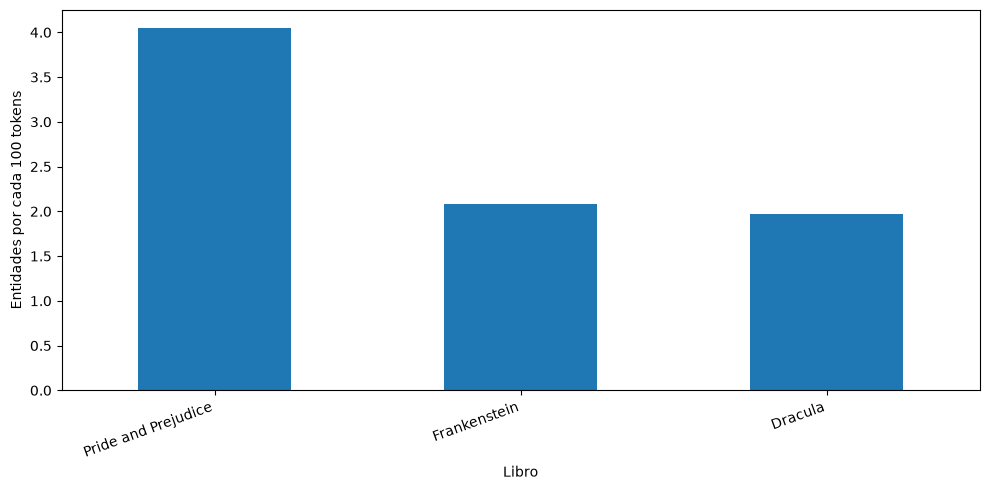

In [124]:
ax = tabla_ner_resumen.plot(
    x='Libro',
    y='Entidades por 100 tokens',
    kind='bar',
    figsize=(10,5),
    legend=False
)
ax.set_ylabel('Entidades por cada 100 tokens')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

**Entre los 3 libros, ¿alguno tiene notablemente más o menos nombres propios que los otros? ¿Tiene esto relación con el género o estilo narrativo del libro?**

Sí, Pride and Prejudice tiene la mayor densidad con alrededor de 4 entidades por cada 100 tokens, frente a unas 2 en Frankenstein y Dracula. Encaja con el género, porque es una novela social de salón donde casi todo es diálogo sobre personas con nombre y tratamiento, y por eso PERSON domina su distribución.

---

### 5. Esquema BIO

In [151]:
TIPOS_ENTIDAD = {'PERSON', 'GPE', 'LOC', 'FAC', 'ORG', 'NORP'}

NO_ENTIDADES = {'Heaven', 'Heavens', 'Providence', 'Fate', 'Fortune', 'Nature', 'Omnipotence',
                'Papa', 'Mamma', 'Aunt', 'Uncle', 'Sir', 'Madam', 'Miss', 'Lady', 'Lord'}

CORRECCIONES = {
    'Netherfield': 'FAC', 'Pemberley': 'FAC', 'Rosings': 'FAC', 'Rosings Park': 'FAC',
    'Longbourn': 'FAC', 'Lucas Lodge': 'FAC',
    'Meryton': 'GPE', 'Derbyshire': 'GPE', 'Hertfordshire': 'GPE', 'Lambton': 'GPE',
    'Brighton': 'GPE', 'Hunsford': 'GPE', 'London': 'GPE',
    'Lydia': 'PERSON', 'Kitty': 'PERSON', 'Jane': 'PERSON', 'Elizabeth': 'PERSON',
    'Darcy': 'PERSON', 'Bingley': 'PERSON', 'Bennet': 'PERSON', 'Wickham': 'PERSON',
    'Collins': 'PERSON', 'Charlotte': 'PERSON', 'Gardiner': 'PERSON', 'Catherine': 'PERSON',
}


def bio_del_modelo(doc):
    etiquetas = ['O'] * len(doc)
    for ent in doc.ents:
        if ent.label_ not in TIPOS_ENTIDAD:
            continue
        for i in range(ent.start, ent.end):
            etiquetas[i] = ('B-' if i == ent.start else 'I-') + ent.label_
    return etiquetas


def spans_desde_bio(etiquetas):
    spans, inicio, tipo = [], None, None
    for i, etiqueta in enumerate(list(etiquetas) + ['O']):
        if etiqueta.startswith('B-'):
            if inicio is not None:
                spans.append((inicio, i, tipo))
            inicio, tipo = i, etiqueta[2:]
        elif etiqueta.startswith('I-') and inicio is not None and etiqueta[2:] == tipo:
            continue
        else:
            if inicio is not None:
                spans.append((inicio, i, tipo))
            inicio, tipo = None, None
    return spans


def limpiar_no_entidades(doc, etiquetas):
    etiquetas = list(etiquetas)
    for inicio, fin, _ in spans_desde_bio(etiquetas):
        texto = doc[inicio:fin].text.strip()
        sin_articulo = texto[4:] if texto.lower().startswith('the ') else texto
        artefacto = (':' in texto or '--' in texto or ',' in texto
                     or not sin_articulo[:1].isupper() or not any(c.isalpha() for c in texto))
        if texto in NO_ENTIDADES or artefacto:
            for i in range(inicio, fin):
                etiquetas[i] = 'O'
    return etiquetas


def aplicar_correcciones(doc, etiquetas, correcciones):
    etiquetas = list(etiquetas)
    ocupado = [False] * len(doc)
    for n in (3, 2, 1):
        for i in range(len(doc) - n + 1):
            if any(ocupado[i:i + n]):
                continue
            superficie = ' '.join(t.text for t in doc[i:i + n])
            if superficie in correcciones:
                tipo = correcciones[superficie]
                for k in range(n):
                    etiquetas[i + k] = ('B-' if k == 0 else 'I-') + tipo
                    ocupado[i + k] = True
    return etiquetas

In [152]:
libro_bio = 'Pride and Prejudice'
info_bio = novelas[libro_bio]
posiciones = {id(o): i for i, o in enumerate(info_bio['oraciones'])}

mejor = None
for oracion in info_bio['muestra']:
    i = posiciones[id(oracion)]
    ventana = info_bio['oraciones'][i:i + 5]
    if len(ventana) < 5:
        continue
    texto = ' '.join(' '.join(o['texto'].split()) for o in ventana)
    if len(texto.split()) > 100:
        continue
    doc = nlp(texto)
    n_ents = sum(1 for e in doc.ents if e.label_ in TIPOS_ENTIDAD)
    if mejor is None or n_ents > mejor[0]:
        mejor = (n_ents, i, texto, doc)

n_ents, i_ini, texto_bio, doc_bio = mejor

print(f'{libro_bio}: oraciones {i_ini + 1} a {i_ini + 5}\n')
for k, o in enumerate(info_bio['oraciones'][i_ini:i_ini + 5], start=1):
    print(f'{k}. {" ".join(o["texto"].split())}')

Pride and Prejudice: oraciones 4614 a 4618

1. He delighted in going to Pemberley, especially when he was least expected.
2. Mr. Bingley and Jane remained at Netherfield only a twelvemonth.
3. So near a vicinity to her mother and Meryton relations was not desirable even to _his_ easy temper, or _her_ affectionate heart.
4. The darling wish of his sisters was then gratified: he bought an estate in a neighbouring county to Derbyshire; and Jane and Elizabeth, in addition to every other source of happiness, were within thirty miles of each other.
5. Kitty, to her very material advantage, spent the chief of her time with her two elder sisters.


In [153]:
bio_modelo = bio_del_modelo(doc_bio)
bio_corregida = limpiar_no_entidades(doc_bio, bio_modelo)
bio_corregida = aplicar_correcciones(doc_bio, bio_corregida, CORRECCIONES)

cambios = [{'Token': doc_bio[i].text, 'BIO del modelo': a, 'BIO corregida': b}
           for i, (a, b) in enumerate(zip(bio_modelo, bio_corregida)) if a != b]
print('Correcciones manuales sobre la salida del modelo:')
display(pd.DataFrame(cambios) if cambios else 'Ninguna')

ANCHO = 12
tokens_bio = [t.text for t in doc_bio]
for inicio in range(0, len(tokens_bio), ANCHO):
    display(pd.DataFrame(
        [tokens_bio[inicio:inicio + ANCHO], bio_corregida[inicio:inicio + ANCHO]],
        index=['token', 'etiqueta BIO'],
        columns=range(inicio, min(inicio + ANCHO, len(tokens_bio))),
    ))

Correcciones manuales sobre la salida del modelo:


,Token,BIO del modelo,BIO corregida
0,Pemberley,B-LOC,B-FAC
1,Netherfield,B-GPE,B-FAC
2,Meryton,B-ORG,B-GPE
3,Derbyshire,O,B-GPE


,0,1,2,3,4,5,6,7,8,9,10,11
token,He,delighted,in,going,to,Pemberley,",",especially,when,he,was,least
etiqueta BIO,O,O,O,O,O,B-FAC,O,O,O,O,O,O


,12,13,14,15,16,17,18,19,20,21,22,23
token,expected,.,Mr.,Bingley,and,Jane,remained,at,Netherfield,only,a,twelvemonth
etiqueta BIO,O,O,O,B-PERSON,O,B-PERSON,O,O,B-FAC,O,O,O


,24,25,26,27,28,29,30,31,32,33,34,35
token,.,So,near,a,vicinity,to,her,mother,and,Meryton,relations,was
etiqueta BIO,O,O,O,O,O,O,O,O,O,B-GPE,O,O


...

,60,61,62,63,64,65,66,67,68,69,70,71
token,then,gratified,:,he,bought,an,estate,in,a,neighbouring,county,to
etiqueta BIO,O,O,O,O,O,O,O,O,O,O,O,O


,72,73,74,75,76,77,78,79,80,81,82,83
token,Derbyshire,;,and,Jane,and,Elizabeth,",",in,addition,to,every,other
etiqueta BIO,B-GPE,O,O,B-PERSON,O,B-PERSON,O,O,O,O,O,O


,84,85,86,87,88,89,90,91,92,93,94,95
token,source,of,happiness,",",were,within,thirty,miles,of,each,other,.
etiqueta BIO,O,O,O,O,O,O,O,O,O,O,O,O


,96,97,98,99,100,101,102,103,104,105,106,107
token,Kitty,",",to,her,very,material,advantage,",",spent,the,chief,of
etiqueta BIO,B-PERSON,O,O,O,O,O,O,O,O,O,O,O


,108,109,110,111,112,113,114,115
token,her,time,with,her,two,elder,sisters,.
etiqueta BIO,O,O,O,O,O,O,O,O


---

### 6. Evaluación de entidades: anotación manual y métricas

In [154]:
from sklearn.metrics import precision_recall_fscore_support

N_GOLD = 40

HONORIFICOS = {'mr', 'mrs', 'miss', 'dr', 'sir', 'lady', 'count', 'professor', 'lord', 'colonel'}

LEXICO = {
    'Pride and Prejudice': {
        'PERSON': ['Elizabeth', 'Lizzy', 'Jane', 'Bennet', 'Darcy', 'Bingley', 'Wickham', 'Collins',
                   'Lydia', 'Kitty', 'Catherine', 'Charlotte', 'Lucas', 'Gardiner', 'Georgiana',
                   'Caroline', 'Hurst', 'Fitzwilliam', 'Denny', 'Forster', 'Maria'],
        'FAC': ['Netherfield', 'Pemberley', 'Rosings', 'Rosings Park', 'Longbourn', 'Lucas Lodge'],
        'GPE': ['London', 'Meryton', 'Brighton', 'Hunsford', 'Derbyshire', 'Hertfordshire', 'Kent',
                'Lambton', 'Newcastle', 'England'],
    },
    'Frankenstein': {
        'PERSON': ['Victor', 'Frankenstein', 'Elizabeth', 'Clerval', 'Henry', 'Justine', 'Walton',
                   'Margaret', 'William', 'Ernest', 'Caroline', 'Beaufort', 'Felix', 'Agatha',
                   'Safie', 'Krempe', 'Waldman', 'Kirwin'],
        'GPE': ['Geneva', 'Ingolstadt', 'Switzerland', 'Germany', 'England', 'Scotland', 'Italy',
                'France', 'Paris', 'London', 'Archangel', 'St. Petersburgh', 'Chamounix', 'Milan',
                'Naples', 'Lucerne', 'Evian', 'Como', 'Greenland', 'Russia'],
        'LOC': ['Mont Blanc', 'Montanvert', 'the Rhine', 'the Alps', 'the Danube'],
    },
    'Dracula': {
        'PERSON': ['Jonathan', 'Harker', 'Mina', 'Lucy', 'Westenra', 'Arthur', 'Holmwood', 'Quincey',
                   'Morris', 'Seward', 'Van Helsing', 'Renfield', 'Dracula', 'Swales', 'Hawkins'],
        'GPE': ['Transylvania', 'Bistritz', 'Klausenburgh', 'Bukovina', 'Munich', 'Vienna',
                'Buda-Pesth', 'Whitby', 'London', 'Exeter', 'Varna', 'Galatz', 'England', 'Europe'],
        'FAC': ['Carfax', 'Borgo Pass', 'Castle Dracula'],
        'LOC': ['the Carpathians', 'the Danube'],
        'NORP': ['Slovaks', 'Szekelys', 'Magyar', 'Saxons', 'Wallachs'],
    },
}


def quitar_honorificos(doc, etiquetas):
    etiquetas = list(etiquetas)
    for i, token in enumerate(doc):
        if etiquetas[i].endswith('PERSON') and token.text.lower().rstrip('.') in HONORIFICOS:
            era_inicio = etiquetas[i].startswith('B-')
            etiquetas[i] = 'O'
            if era_inicio and i + 1 < len(etiquetas) and etiquetas[i + 1] == 'I-PERSON':
                etiquetas[i + 1] = 'B-PERSON'
    return etiquetas


def anotacion_manual(doc, libro):
    correcciones = {nombre: tipo for tipo, nombres in LEXICO[libro].items() for nombre in nombres}
    etiquetas = bio_del_modelo(doc)
    etiquetas = quitar_honorificos(doc, etiquetas)
    etiquetas = limpiar_no_entidades(doc, etiquetas)
    etiquetas = aplicar_correcciones(doc, etiquetas, correcciones)
    return etiquetas

In [155]:
datos_eval = {}
for titulo, info_libro in novelas.items():
    registros = []
    for k, o in enumerate(info_libro['muestra'][:N_GOLD], start=1):
        doc = nlp(' '.join(o['texto'].split()))
        registros.append({'oracion': k, 'doc': doc,
                          'pred': bio_del_modelo(doc),
                          'gold': anotacion_manual(doc, titulo)})
    datos_eval[titulo] = registros

for titulo, registros in datos_eval.items():
    filas = [{'Oración': r['oracion'], 'Span': r['doc'][a:b].text, 'Tipo': t}
             for r in registros for a, b, t in spans_desde_bio(r['gold'])]
    print(f'\n=== {titulo}: {len(filas)} entidades anotadas en {N_GOLD} oraciones ===')
    display(pd.DataFrame(filas))


=== Pride and Prejudice: 35 entidades anotadas en 40 oraciones ===


,Oración,Span,Tipo
0,1,Darcy,PERSON
1,2,Catherine,PERSON
2,2,Lydia,PERSON
3,2,Meryton,GPE
4,5,Darcy,PERSON
5,9,Vanity,GPE
6,11,Gardiner,PERSON
7,11,Wickham,PERSON
8,13,London,GPE
9,13,Elizabeth,PERSON



=== Frankenstein: 14 entidades anotadas en 40 oraciones ===


,Oración,Span,Tipo
0,5,Felix,PERSON
1,11,Safie,PERSON
2,12,Frankenstein,PERSON
3,14,Safie,PERSON
4,14,Turks,NORP
5,14,Safie,PERSON
6,18,Elizabeth,PERSON
7,24,London,GPE
8,31,Elizabeth,PERSON
9,31,Ingolstadt,GPE



=== Dracula: 24 entidades anotadas en 40 oraciones ===


,Oración,Span,Tipo
0,7,Lucy,PERSON
1,8,Lucy,PERSON
2,10,Voivode,PERSON
3,10,Dracula,PERSON
4,10,Turk,PERSON
5,10,Turkey,GPE
6,13,Jonathan’s,PERSON
7,15,Czarina Catherine,PERSON
8,18,Morris,PERSON
9,20,Lucy,PERSON


In [156]:
def tipo_por_token(etiquetas):
    return [e.split('-')[-1] for e in etiquetas]


resultados_eval = []

for titulo, registros in datos_eval.items():
    gold_tokens = [e for r in registros for e in tipo_por_token(r['gold'])]
    pred_tokens = [e for r in registros for e in tipo_por_token(r['pred'])]
    etiquetas = sorted(set(gold_tokens + pred_tokens) - {'O'})
    p_tok, r_tok, f1_tok, _ = precision_recall_fscore_support(
        gold_tokens, pred_tokens, labels=etiquetas, average='micro', zero_division=0)

    gold_spans = {(r['oracion'],) + s for r in registros for s in spans_desde_bio(r['gold'])}
    pred_spans = {(r['oracion'],) + s for r in registros for s in spans_desde_bio(r['pred'])}
    tp = len(gold_spans & pred_spans)
    p_ent = tp / len(pred_spans) if pred_spans else 0
    r_ent = tp / len(gold_spans) if gold_spans else 0
    f1_ent = 2 * p_ent * r_ent / (p_ent + r_ent) if p_ent + r_ent else 0

    resultados_eval.append({'Libro': titulo, 'Evaluación': '(a) Por token',
                            'Entidades gold': len(gold_spans), 'Entidades predichas': len(pred_spans),
                            'Precisión': round(p_tok, 3), 'Recall': round(r_tok, 3), 'F1': round(f1_tok, 3)})
    resultados_eval.append({'Libro': titulo, 'Evaluación': '(b) Por entidad completa',
                            'Entidades gold': len(gold_spans), 'Entidades predichas': len(pred_spans),
                            'Precisión': round(p_ent, 3), 'Recall': round(r_ent, 3), 'F1': round(f1_ent, 3)})

tabla_evaluacion_ner = pd.DataFrame(resultados_eval)
tabla_evaluacion_ner

,Libro,Evaluación,Entidades gold,Entidades predichas,Precisión,Recall,F1
0,Pride and Prejudice,(a) Por token,35,37,0.682,0.811,0.741
1,Pride and Prejudice,(b) Por entidad completa,35,37,0.676,0.714,0.694
2,Frankenstein,(a) Por token,14,16,0.500,0.643,0.562
3,Frankenstein,(b) Por entidad completa,14,16,0.438,0.500,0.467
4,Dracula,(a) Por token,24,22,0.973,0.973,0.973
5,Dracula,(b) Por entidad completa,24,22,0.864,0.792,0.826


**Compare los resultados entre sí: ¿la evaluación por token da una impresión más optimista que la evaluación por entidad completa en los 3 casos? ¿El modelo funciona notablemente mejor en algún libro que en otro?**

Sí, la evaluación por token da una impresión más optimista en los tres casos, porque el F1 por token es mayor que el F1 por entidad completa. En Pride and Prejudice la diferencia es pequeña, de 0.741 a 0.694, pero en Frankenstein baja más, de 0.562 a 0.467, y en Dracula también se nota una caida de 0.973 a 0.826. Esto puede estar pasando porque una entidad puede tener algunos tokens correctos, pero para contar como entidad completa el modelo debe acertar todo el span y el tipo.